## Build a Basic Chatbot with Langgraph(Graph API)

In [2]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [3]:
class State(TypedDict):
    # Messages have the type "list". The 'add_messages' funtion
    # in the annotation defines how this state key should be updated
    # (int this case, it appends messages to the list, rather than the overwriting them)
    messages:Annotated[list,add_messages]

graph_builder = StateGraph(State)

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [14]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="openai/gpt-oss-20b")

In [15]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.3', 'langchain': '1.4.0'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001B65C8CDF10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001B65C8CE510>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [7]:
llm2 = init_chat_model("groq:openai/gpt-oss-20b")
llm2

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.3', 'langchain': '1.4.0'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001B65BDB7680>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001B65B6413A0>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [16]:
## Node Functionality
def chat_bot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [17]:
graph_builder= StateGraph(State)

#Adding Node 
graph_builder.add_node("llmchatbot", chat_bot)
# Adding Edges
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

# Compile the graph
graph = graph_builder.compile()


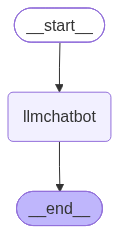

In [18]:
# Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [20]:
response =graph.invoke({"messages":"Hi"})

In [22]:
response["messages"][-1].content

'Hello! How can I help you today?'

In [25]:
for event in graph.stream({"messages":"How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm doing well—thanks for asking! How about you?


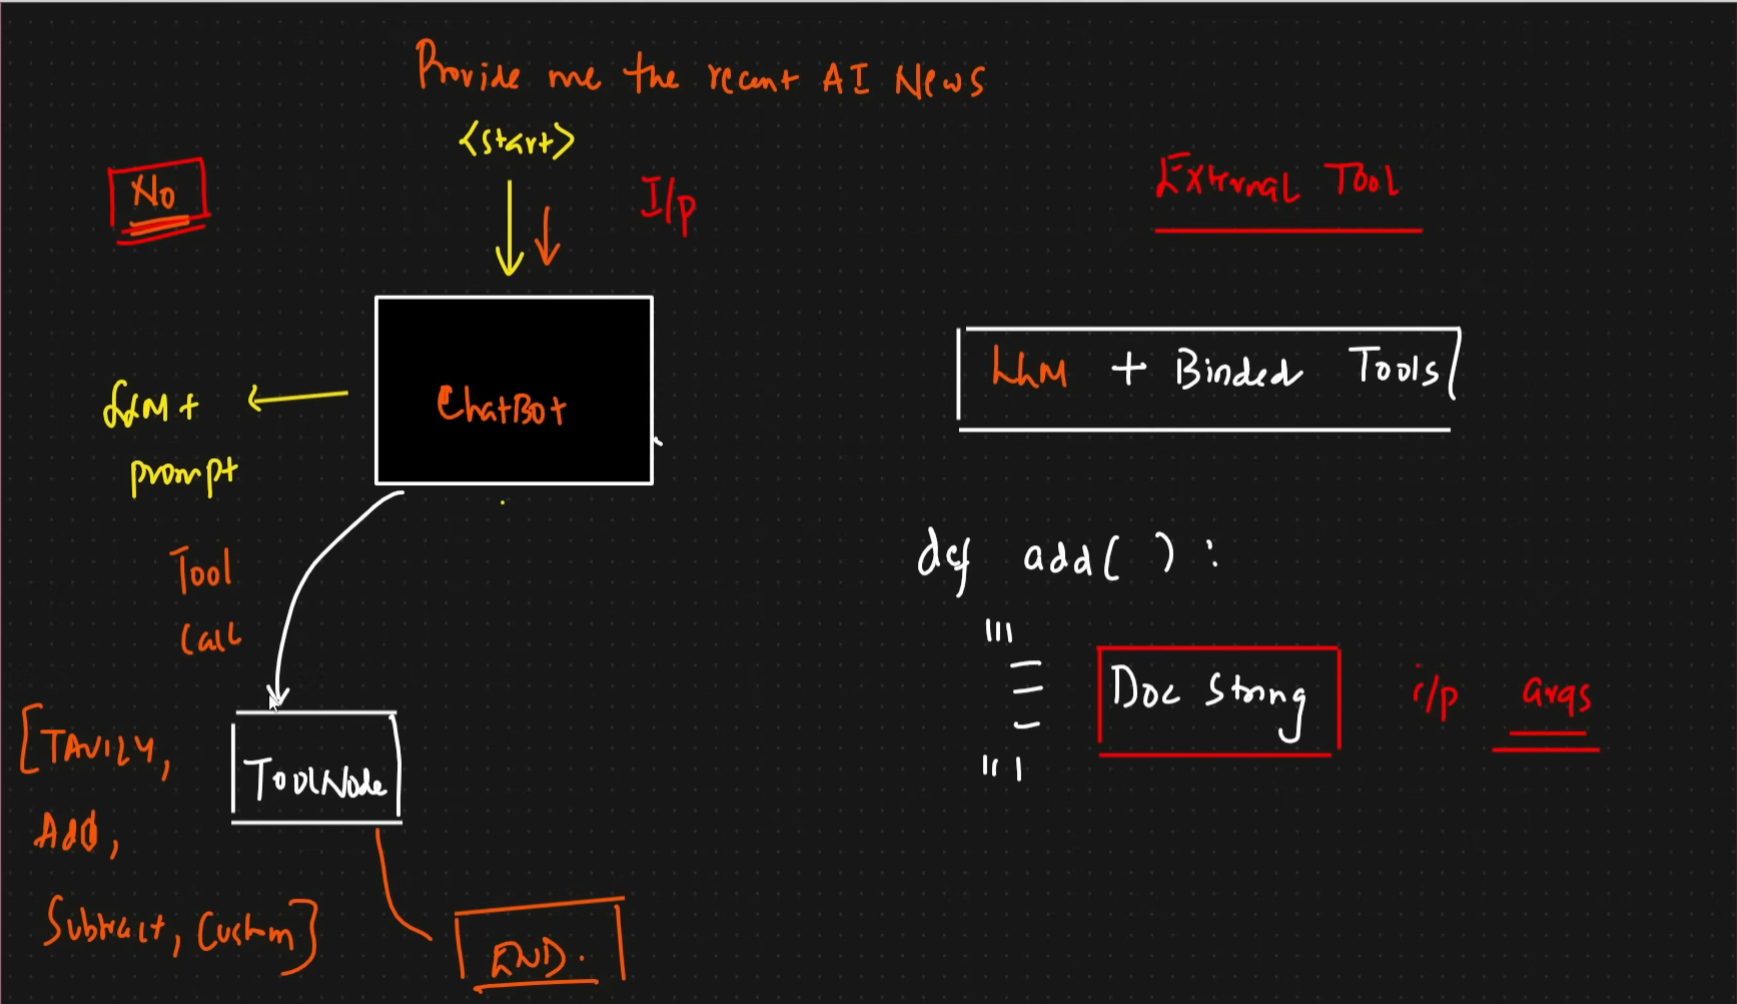